# Fase 1 — Validación GAF
Verifica que `gaf/transform.py` construye imágenes correctas.

In [1]:
import sys
sys.path.insert(0, '/app')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from gaf.transform import normalize_series, build_gasf, build_gaf_image, invert_diagonal

print('Imports OK')

Imports OK


## 1. Series sintéticas

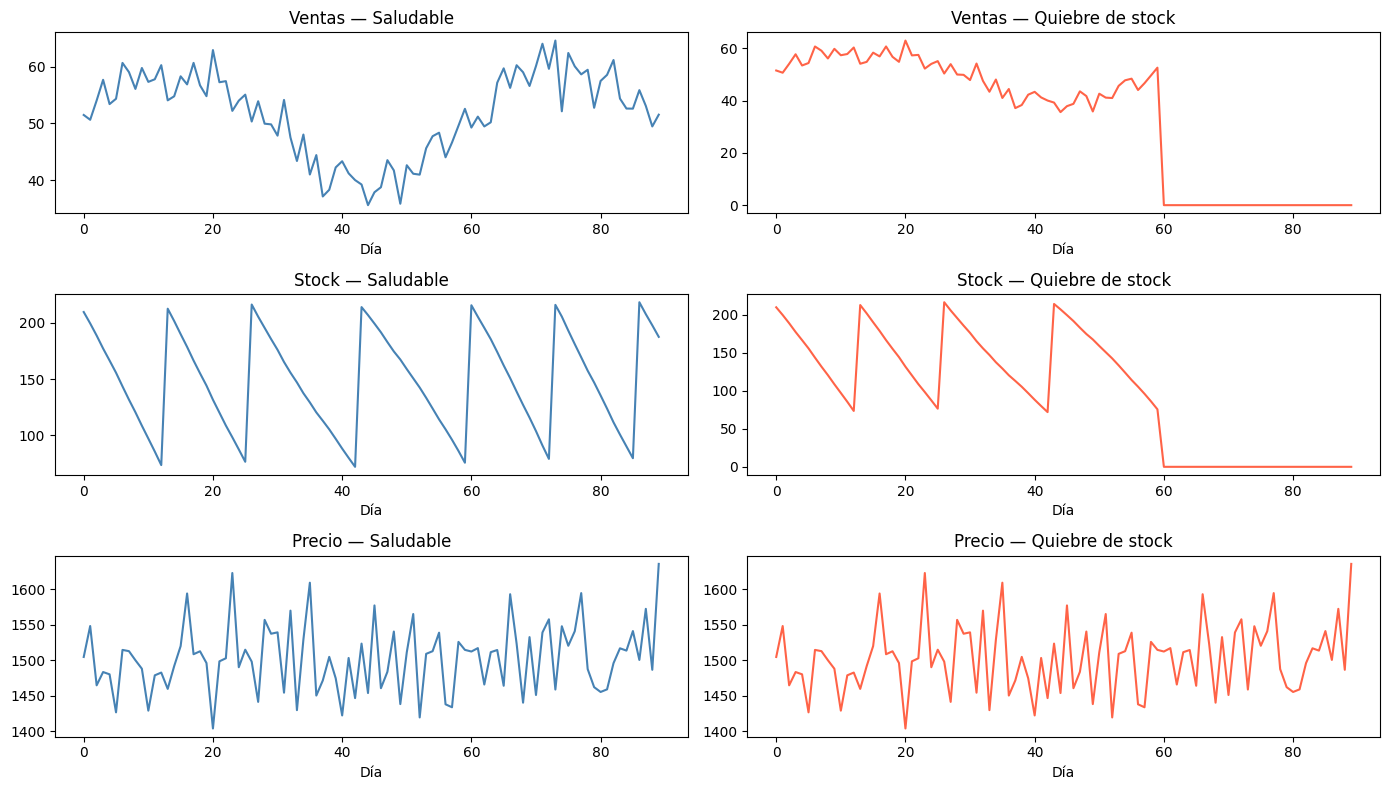

Series sintéticas generadas


In [2]:
np.random.seed(42)
N = 90

# Serie saludable: tendencia suave + ruido
ventas_ok   = 50 + 10 * np.sin(np.linspace(0, 3*np.pi, N)) + np.random.normal(0, 3, N)
stock_ok    = 200 - np.cumsum(np.clip(ventas_ok / 5, 0, None)) % 150 + 20
precio_ok   = 1500 + np.random.normal(0, 50, N)
ventas_ok   = np.clip(ventas_ok, 0, None)
stock_ok    = np.clip(stock_ok,  0, None)

# Serie con quiebre de stock: ventas caen a 0 en días 60-90
ventas_qs   = ventas_ok.copy()
stock_qs    = stock_ok.copy()
precio_qs   = precio_ok.copy()
ventas_qs[60:] = 0.0
stock_qs[60:]  = 0.0

fig, axes = plt.subplots(3, 2, figsize=(14, 8))
labels = ['Ventas', 'Stock', 'Precio']
series_ok = [ventas_ok, stock_ok, precio_ok]
series_qs = [ventas_qs, stock_qs, precio_qs]

for i, (label, s_ok, s_qs) in enumerate(zip(labels, series_ok, series_qs)):
    axes[i,0].plot(s_ok, color='steelblue')
    axes[i,0].set_title(f'{label} — Saludable')
    axes[i,0].set_xlabel('Día')
    axes[i,1].plot(s_qs, color='tomato')
    axes[i,1].set_title(f'{label} — Quiebre de stock')
    axes[i,1].set_xlabel('Día')

plt.tight_layout()
plt.savefig('/app/outputs/visualizations/fase1_series.png', dpi=100)
plt.show()
print('Series sintéticas generadas')

## 2. Imagen GAF — Serie saludable

In [3]:
img_ok = build_gaf_image(ventas_ok, stock_ok, precio_ok)
print(f'Shape imagen GAF: {img_ok.shape}')   # debe ser (90, 90, 3)
print(f'Min: {img_ok.min():.4f}  Max: {img_ok.max():.4f}')  # debe estar en [-1, 1]

Shape imagen GAF: (90, 90, 3)
Min: -1.0000  Max: 1.0000


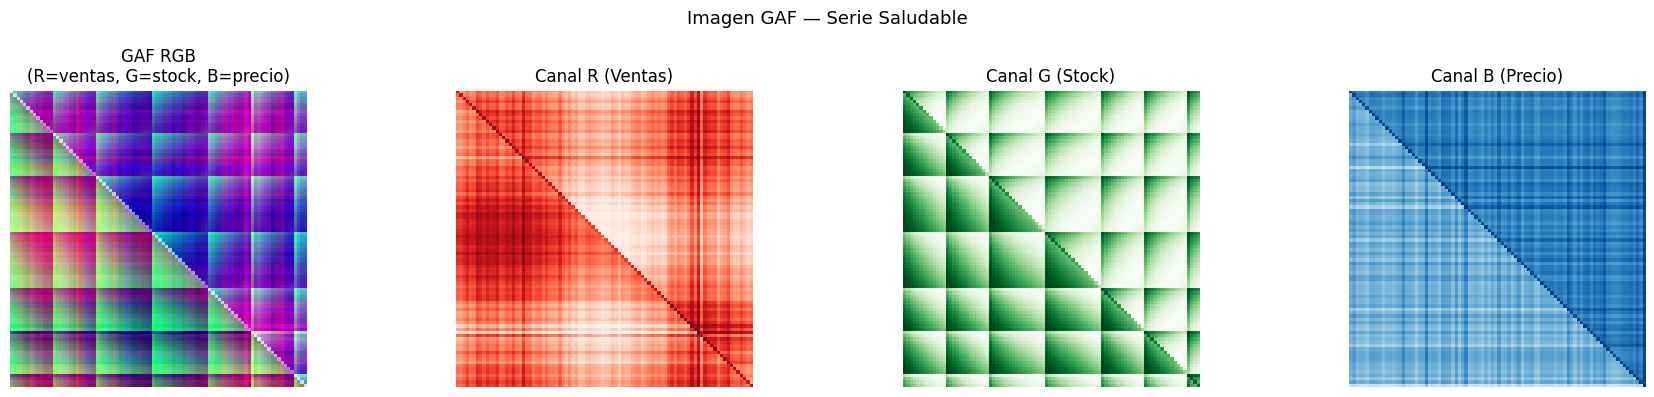

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Imagen RGB compuesta
img_display = (img_ok + 1) / 2  # escalar [-1,1] → [0,1] para imshow
axes[0].imshow(img_display)
axes[0].set_title('GAF RGB\n(R=ventas, G=stock, B=precio)')
axes[0].axis('off')

# Canal por canal
channel_names = ['Canal R (Ventas)', 'Canal G (Stock)', 'Canal B (Precio)']
cmaps = ['Reds', 'Greens', 'Blues']
for i, (name, cmap) in enumerate(zip(channel_names, cmaps)):
    axes[i+1].imshow(img_ok[:,:,i], cmap=cmap, vmin=-1, vmax=1)
    axes[i+1].set_title(name)
    axes[i+1].axis('off')

plt.suptitle('Imagen GAF — Serie Saludable', fontsize=13)
plt.tight_layout()
plt.savefig('/app/outputs/visualizations/fase1_gaf_saludable.png', dpi=100)
plt.show()

## 3. Comparación: Saludable vs Quiebre de stock

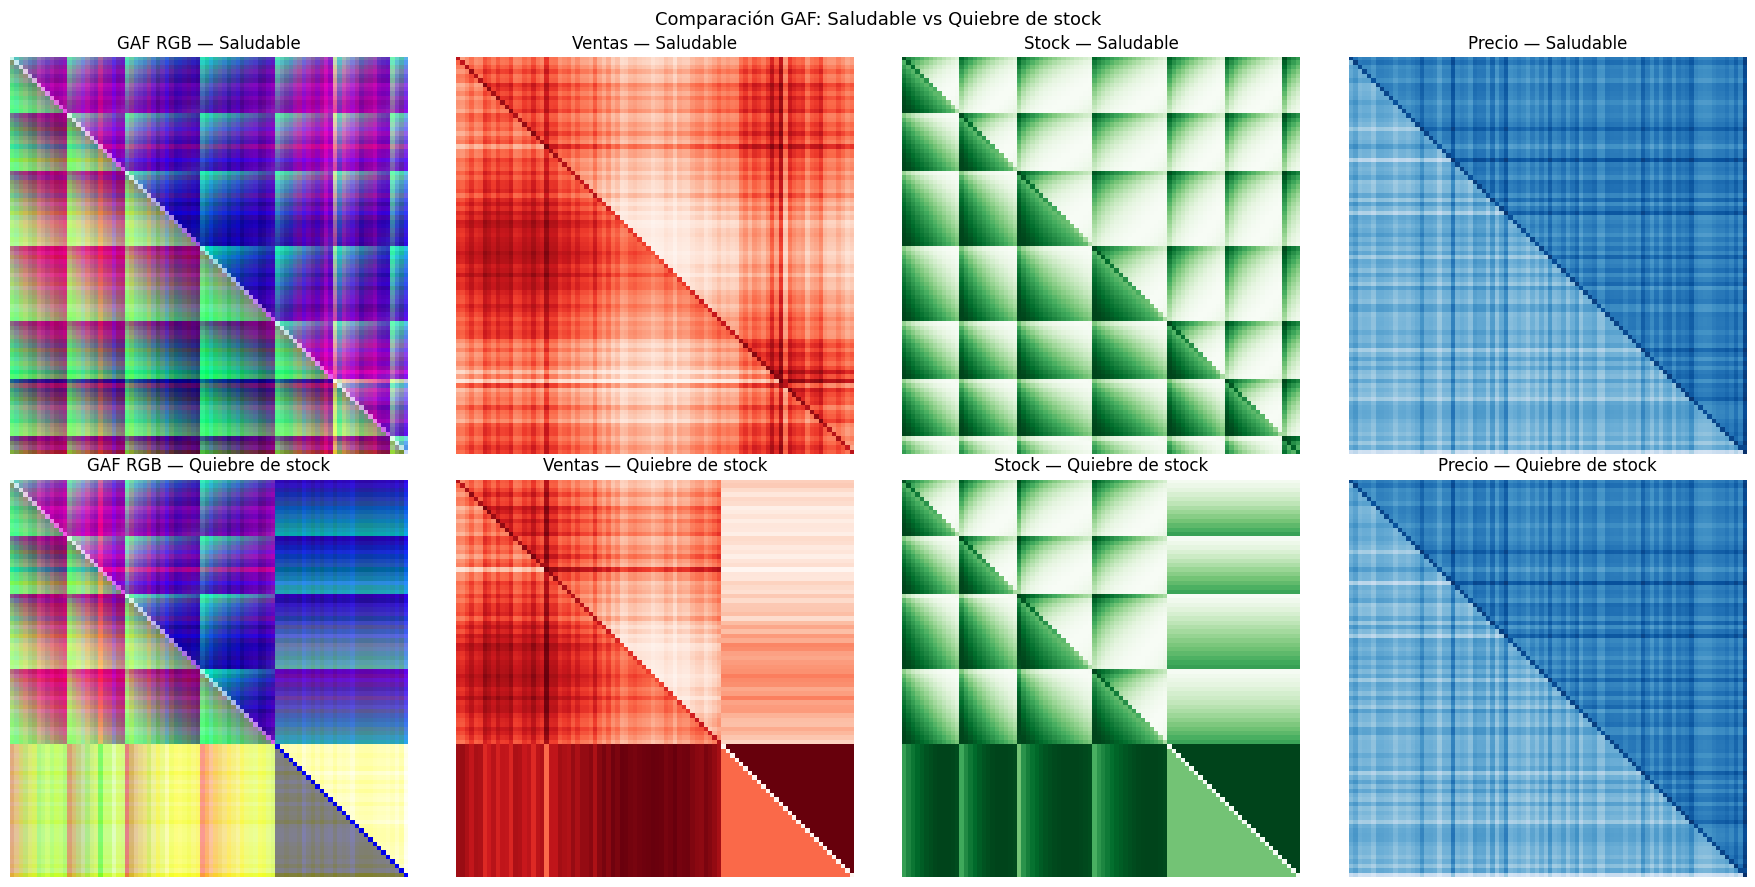

Las firmas cromáticas deben ser visualmente distintas en los canales R y G


In [5]:
img_qs = build_gaf_image(ventas_qs, stock_qs, precio_qs)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for row, (img, title) in enumerate([(img_ok, 'Saludable'), (img_qs, 'Quiebre de stock')]):
    img_display = (img + 1) / 2
    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f'GAF RGB — {title}')
    axes[row, 0].axis('off')

    for i, (name, cmap) in enumerate(zip(['Ventas','Stock','Precio'], ['Reds','Greens','Blues'])):
        axes[row, i+1].imshow(img[:,:,i], cmap=cmap, vmin=-1, vmax=1)
        axes[row, i+1].set_title(f'{name} — {title}')
        axes[row, i+1].axis('off')

plt.suptitle('Comparación GAF: Saludable vs Quiebre de stock', fontsize=13)
plt.tight_layout()
plt.savefig('/app/outputs/visualizations/fase1_comparacion.png', dpi=100)
plt.show()
print('Las firmas cromáticas deben ser visualmente distintas en los canales R y G')

## 4. Verificación: la diagonal recupera los valores originales

In [6]:
_, min_ventas, max_ventas = normalize_series(ventas_ok)
_, min_stock,  max_stock  = normalize_series(stock_ok)
_, min_precio, max_precio = normalize_series(precio_ok)

meta_ok = {
    'ventas': (min_ventas, max_ventas),
    'stock':  (min_stock,  max_stock),
    'precio': (min_precio, max_precio),
}

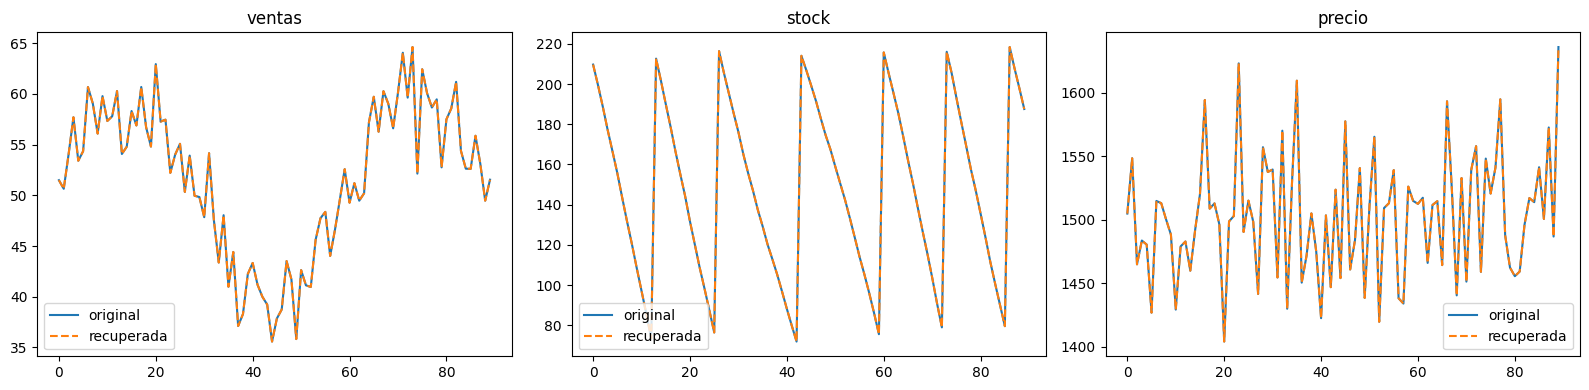

ventas    MAE recuperación: 0.000003
stock     MAE recuperación: 0.000006
precio    MAE recuperación: 0.000047


In [7]:
canales = ['ventas', 'stock', 'precio']

recovered = {
    'ventas': invert_diagonal(img_ok[:, :, 0], *meta_ok['ventas']),
    'stock':  invert_diagonal(img_ok[:, :, 1], *meta_ok['stock']),
    'precio': invert_diagonal(img_ok[:, :, 2], *meta_ok['precio']),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
series_orig = {'ventas': ventas_ok, 'stock': stock_ok, 'precio': precio_ok}

for ax, canal in zip(axes, canales):
    ax.plot(series_orig[canal], label='original')
    ax.plot(recovered[canal],   label='recuperada', linestyle='--')
    ax.set_title(canal)
    ax.legend()

plt.tight_layout()
plt.savefig('/app/outputs/visualizations/fase1_diagonal.png', dpi=100)
plt.show()

for name in ['ventas', 'stock', 'precio']:
    mae = np.mean(np.abs(series_orig[name] - recovered[name]))
    print(f'{name:8s}  MAE recuperación: {mae:.6f}')

## 5. Resumen final

In [8]:
print('=== RESUMEN FASE 1 ===')
print(f'Shape imagen GAF:        {img_ok.shape}  ← debe ser (90, 90, 3)')
print(f'Rango valores:           [{img_ok.min():.4f}, {img_ok.max():.4f}]  ← debe estar en [-1, 1]')
print(f'Dtype:                   {img_ok.dtype}  ← debe ser float32')
for name in ['ventas', 'stock', 'precio']:
    mae = np.mean(np.abs(series_orig[name] - recovered[name]))
    estado = '✅' if mae < 1.0 else '⚠️'
    print(f'MAE recuperación {name:8s}: {mae:.6f}  {estado}')

=== RESUMEN FASE 1 ===
Shape imagen GAF:        (90, 90, 3)  ← debe ser (90, 90, 3)
Rango valores:           [-1.0000, 1.0000]  ← debe estar en [-1, 1]
Dtype:                   float32  ← debe ser float32
MAE recuperación ventas  : 0.000003  ✅
MAE recuperación stock   : 0.000006  ✅
MAE recuperación precio  : 0.000047  ✅


In [ ]:
import pandas as pd
df = pd.read_csv('/app/data/raw/ventas_diarias.csv', sep=";", low_memory=False)
df['date'] = pd.to_datetime(df['date'])
print(f"Rango: {df['date'].min()} → {df['date'].max()}")
print(f"Días únicos: {df['date'].nunique()}")
print(f"Locales únicos: {df['store_id'].nunique()}")
print(f"Productos únicos: {df['retailer_sku'].nunique()}")
print(f"Filas totales: {len(df)}")

Rango: 2024-03-11 00:00:00 → 2026-03-15 00:00:00
Días únicos: 733
Locales únicos: 1029
Productos únicos: 179
Filas totales: 6062390


In [ ]:
combos = df.groupby(['store_id', 'retailer_sku'])['date'].nunique()
print(f"Combinaciones local+producto con datos: {len(combos)}")
print(f"Días promedio por combinación: {combos.mean():.1f}")
print(f"Combinaciones con >= 90 días: {(combos >= 90).sum()}")
print(f"Combinaciones con >= 180 días: {(combos >= 180).sum()}")

Combinaciones local+producto con datos: 15165
Días promedio por combinación: 396.6
Combinaciones con >= 90 días: 12713
Combinaciones con >= 180 días: 10782
